In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append('..')

In [2]:
from src.data.data_cleaning import  (
    load_config, load_raw, clean_sales_format, remove_duplicate_dates,
    fill_date_gaps, handle_outliers, handle_missing, run_cleaning,
)

In [3]:
config = load_config('config.yaml')

In [4]:
df_raw = pd.read_csv(config['data']['raw_path'])
df_raw.head()

,date,sales,promo,is_holiday
0,2023-01-01,380.2,0,1
1,2023-01-02,236.7,0,0
2,2023-01-03,232.4,0,0
3,2023-01-04,235.2,0,0
4,2023-01-05,345.8,1,0


In [5]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1096 entries, 0 to 1095
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        1096 non-null   object 
 1   sales       1074 non-null   float64
 2   promo       1096 non-null   int64  
 3   is_holiday  1096 non-null   int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 34.4+ KB


In [6]:
df_raw.describe()

,sales,promo,is_holiday
count,1074.000000,1096.000000,1096.000000
mean,309.511732,0.145985,0.010949
std,167.605694,0.353253,0.104110
min,0.000000,0.000000,0.000000
25%,255.025000,0.000000,0.000000
50%,300.950000,0.000000,0.000000
75%,345.150000,0.000000,0.000000
max,3372.000000,1.000000,1.000000


In [7]:
df_raw.isna().sum()

date           0
sales         22
promo          0
is_holiday     0
dtype: int64

In [8]:
df_raw.duplicated().sum()

np.int64(4)

In [12]:
print("Dtype sales:", df_raw["sales"].dtype)
print("Missing values:\n", df_raw.isnull().sum())
print("Tanggal duplikat:", df_raw["date"].duplicated().sum())
df_raw["date"] = pd.to_datetime(df_raw["date"])
expected_days = (df_raw["date"].max() - df_raw["date"].min()).days + 1
print("Jumlah baris:", len(df_raw), "| Seharusnya (tanpa gap/duplikat):", expected_days)

Dtype sales: float64
Missing values:
 date           0
sales         22
promo          0
is_holiday     0
dtype: int64
Tanggal duplikat: 4
Jumlah baris: 1096 | Seharusnya (tanpa gap/duplikat): 1095


In [13]:
df_step1 = clean_sales_format(df_raw, config)
print("Dtype setelah dibersihkan:", df_step1["sales"].dtype)
df_step1[df_raw["sales"].astype(str).str.contains(",", na=False)]  # cek baris yang tadinya ada koma

Dtype setelah dibersihkan: float64


,date,sales,promo,is_holiday


In [14]:
df_step2 = remove_duplicate_dates(df_step1, config)
print("Shape sebelum:", df_step1.shape, "| sesudah:", df_step2.shape)
print("Duplikat tersisa:", df_step2["date"].duplicated().sum())

Shape sebelum: (1096, 4) | sesudah: (1092, 4)
Duplikat tersisa: 0


In [15]:
df_step3 = fill_date_gaps(df_step2, config)
print("Shape sebelum:", df_step2.shape, "| sesudah:", df_step3.shape)

full_range_len = (df_step3["date"].max() - df_step3["date"].min()).days + 1
print("Panjang date range:", full_range_len, "| Jumlah baris:", len(df_step3))

Shape sebelum: (1092, 4) | sesudah: (1095, 4)
Panjang date range: 1095 | Jumlah baris: 1095


Outlier terdeteksi (jadi NaN): 17


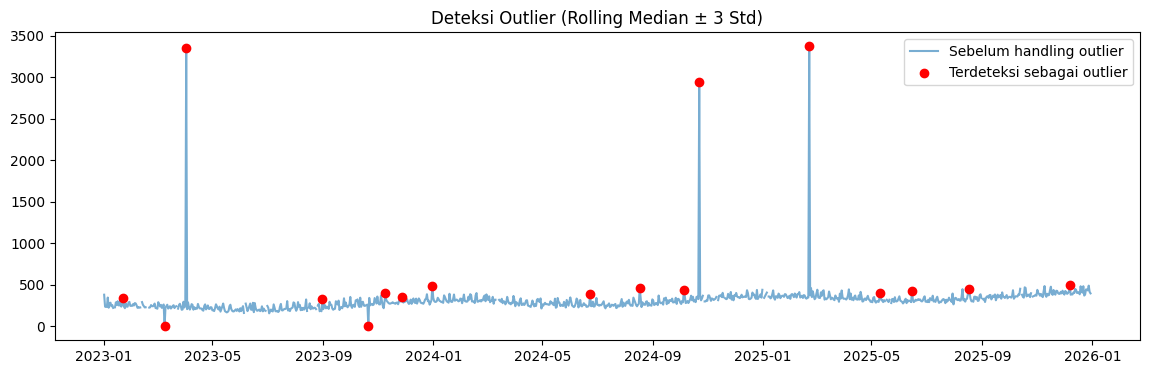

In [16]:
import matplotlib.pyplot as plt

outlier_marked = handle_outliers(df_step3, config)
n_outliers_detected = outlier_marked["sales"].isna().sum() - df_step3["sales"].isna().sum()
print("Outlier terdeteksi (jadi NaN):", n_outliers_detected)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_step3["date"], df_step3["sales"], label="Sebelum handling outlier", alpha=0.6)
ax.scatter(
    df_step3.loc[outlier_marked["sales"].isna() & df_step3["sales"].notna(), "date"],
    df_step3.loc[outlier_marked["sales"].isna() & df_step3["sales"].notna(), "sales"],
    color="red", label="Terdeteksi sebagai outlier", zorder=5,
)
ax.legend()
ax.set_title("Deteksi Outlier (Rolling Median ± 3 Std)")
plt.show()

In [17]:
df_final = handle_missing(outlier_marked, config)
print("Missing values setelah interpolasi:", df_final["sales"].isnull().sum())

Missing values setelah interpolasi: 0


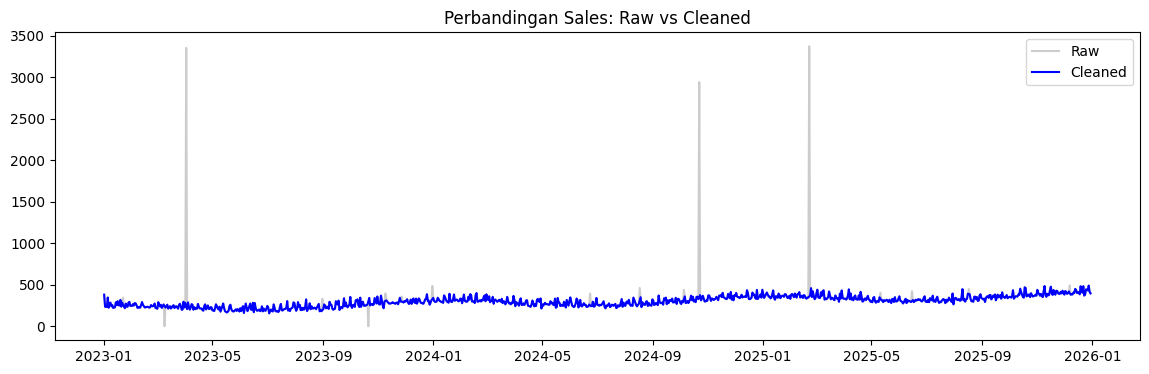

In [18]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_raw["date"], pd.to_numeric(df_raw["sales"].astype(str).str.replace(",", ""), errors="coerce"),
        label="Raw", alpha=0.4, color="gray")
ax.plot(df_final["date"], df_final["sales"], label="Cleaned", color="blue")
ax.legend()
ax.set_title("Perbandingan Sales: Raw vs Cleaned")
plt.show()

In [19]:
df_clean = run_cleaning(config)
df_clean.info()
print(df_clean.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        1095 non-null   datetime64[ns]
 1   sales       1095 non-null   float64       
 2   promo       1095 non-null   int64         
 3   is_holiday  1095 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(2)
memory usage: 34.3 KB
date          0
sales         0
promo         0
is_holiday    0
dtype: int64
